In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file = '../data/outs/all_time.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [3]:
df.dtypes

nome      object
n          int64
m          int64
c          int64
fila      object
run        int64
l1         int64
l2         int64
llc        int64
cycles     int64
dtype: object

## Tempo de execução por quantidade de vértices

In [4]:
df_run_n = (
    df.groupby(['nome', 'fila'])['run']
      .agg(['mean', 'std', 'var'])
      .reset_index()
)
df_run_n

,nome,fila,mean,std,var
0,BAY,1LVBQ,238.5,8.436034,71.166667
1,BAY,2LVBQ,220.4,4.005552,16.044444
2,BAY,4AH,289.7,4.945256,24.455556
3,BAY,BINH,304.5,7.531416,56.722222
4,CAL,1LVBQ,1611.6,14.622661,213.822222
5,CAL,2LVBQ,1453.7,45.419159,2062.900000
6,CAL,4AH,1830.0,10.593499,112.222222
7,CAL,BINH,1904.2,16.382918,268.400000
8,FLA,1LVBQ,930.9,227.858362,51919.433333
9,FLA,2LVBQ,753.7,5.313505,28.233333


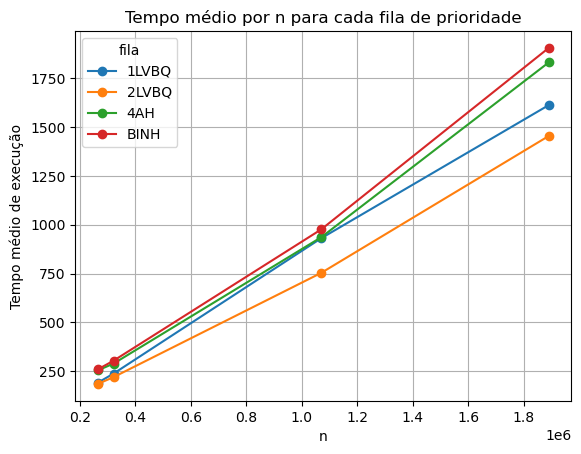

In [5]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlação entre métricas e tempo de execução

In [6]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [7]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)
df_run_miss

,nome,fila,run,l1,l2,llc,cycles,l1_mr,l2_mr,llc_mr
0,BAY,1LVBQ,238.5,4691965.9,3540198.8,273854.8,3.300414e+08,0.014226,0.010734,0.000829
1,BAY,2LVBQ,220.4,3504837.6,1900501.0,151119.2,3.187386e+08,0.010997,0.005963,0.000474
2,BAY,4AH,289.7,2165060.8,1466380.2,159736.4,4.212711e+08,0.005140,0.003481,0.000379
3,BAY,BINH,304.5,2182745.0,1477331.5,172819.3,4.441524e+08,0.004914,0.003326,0.000389
4,CAL,1LVBQ,1611.6,30871536.9,27401494.0,2006804.4,2.148164e+09,0.014373,0.012758,0.000934
5,CAL,2LVBQ,1453.7,23874295.9,14432625.7,1242274.1,2.015807e+09,0.011846,0.007163,0.000615
6,CAL,4AH,1830.0,16019570.1,10766720.5,1067576.0,2.627392e+09,0.006097,0.004098,0.000406
7,CAL,BINH,1904.2,16030804.2,10835650.1,1075554.2,2.741457e+09,0.005848,0.003952,0.000392
8,FLA,1LVBQ,930.9,17195013.2,14249943.4,892656.5,1.194772e+09,0.014394,0.011929,0.000747
9,FLA,2LVBQ,753.7,11583247.8,6715983.8,433148.4,1.105574e+09,0.010478,0.006075,0.000392
